In [1]:
import pandas as pd
import numpy as np

# Loading Data

In [2]:
df_fear = pd.read_csv(r'/kaggle/input/datasets/aaryannayan/fear-greed/fear_greed_index.csv')

In [3]:
df_history = pd.read_csv(r'/kaggle/input/datasets/aaryannayan/fear-greed/historical_data.csv')

# Understanding Data

In [4]:
df_fear.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [5]:
df_history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [6]:
df_history.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [7]:
df_fear.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


# Data Preprocessing

In [8]:
df_history["Timestamp IST"] = pd.to_datetime(
    df_history["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
)

In [9]:
df_fear["timestamp"] = pd.to_datetime(
    df_fear["timestamp"],
    unit="s"
)

In [10]:
df_history["Timestamp IST"] = df_history["Timestamp IST"].dt.tz_localize("Asia/Kolkata")

In [11]:
df_fear["timestamp"] = df_fear["timestamp"].dt.tz_localize("UTC").dt.tz_convert("Asia/Kolkata")

In [12]:
df_history = df_history.sort_values("Timestamp IST")
df_fear = df_fear.sort_values("timestamp")

In [13]:
merged = pd.merge_asof(
    df_history,
    df_fear,
    left_on="Timestamp IST",
    right_on="timestamp",
    direction="backward"
)

In [14]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype                       
---  ------            --------------   -----                       
 0   Account           211224 non-null  object                      
 1   Coin              211224 non-null  object                      
 2   Execution Price   211224 non-null  float64                     
 3   Size Tokens       211224 non-null  float64                     
 4   Size USD          211224 non-null  float64                     
 5   Side              211224 non-null  object                      
 6   Timestamp IST     211224 non-null  datetime64[ns, Asia/Kolkata]
 7   Start Position    211224 non-null  float64                     
 8   Direction         211224 non-null  object                      
 9   Closed PnL        211224 non-null  float64                     
 10  Transaction Hash  211224 non-null  object               

In [15]:
merged.shape

(211224, 20)

In [16]:
drop_col = [
    "Transaction Hash",
    "Order ID",
    "Trade ID",
    "Timestamp"  
]  
merged = merged.drop(columns=drop_col, errors="ignore")

In [17]:
merged = merged.drop(columns='Account')

In [18]:
merged.head()

,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Crossed,Fee,timestamp,value,classification,date
0,ETH,1897.9,0.08240,156.39,BUY,2023-05-01 01:06:00+05:30,0.0967,Open Long,0.0,True,0.000000,2023-04-30 11:00:00+05:30,60,Greed,2023-04-30
1,ETH,1898.6,0.07220,137.08,BUY,2023-05-01 01:06:00+05:30,0.1791,Open Long,0.0,True,0.000000,2023-04-30 11:00:00+05:30,60,Greed,2023-04-30
2,ETH,1897.9,0.09670,183.53,BUY,2023-05-01 01:06:00+05:30,0.0000,Open Long,0.0,True,0.000000,2023-04-30 11:00:00+05:30,60,Greed,2023-04-30
3,BTC,41866.0,0.58211,24370.62,SELL,2023-12-05 03:11:00+05:30,-0.0150,Open Short,0.0,True,6.092654,2023-12-04 11:00:00+05:30,74,Greed,2023-12-04
4,BTC,41867.0,0.01500,628.00,SELL,2023-12-05 03:11:00+05:30,0.0000,Open Short,0.0,True,0.157001,2023-12-04 11:00:00+05:30,74,Greed,2023-12-04


In [19]:
sample = merged[['Timestamp IST','Side','Direction','Start Position','Size USD','Closed PnL','value','classification']]

In [20]:
sample.head()

,Timestamp IST,Side,Direction,Start Position,Size USD,Closed PnL,value,classification
0,2023-05-01 01:06:00+05:30,BUY,Open Long,0.0967,156.39,0.0,60,Greed
1,2023-05-01 01:06:00+05:30,BUY,Open Long,0.1791,137.08,0.0,60,Greed
2,2023-05-01 01:06:00+05:30,BUY,Open Long,0.0000,183.53,0.0,60,Greed
3,2023-12-05 03:11:00+05:30,SELL,Open Short,-0.0150,24370.62,0.0,74,Greed
4,2023-12-05 03:11:00+05:30,SELL,Open Short,0.0000,628.00,0.0,74,Greed


# Correlation

In [21]:

import seaborn as sns
import matplotlib.pyplot as plt

In [22]:
corelation_df = sample[['Timestamp IST','Side','Direction','Start Position',
             'Size USD','Closed PnL','value','classification']].copy()

In [23]:
corelation_df.columns = corelation_df.columns.str.strip().str.lower().str.replace(" ", "_")

In [24]:
corelation_df["direction"] = corelation_df["direction"].map({"Buy": 1, "Sell": 0 , "Open Long": 2,
    "Close Long": 3,
    "Open Short": 4,
    "Close Short": 5})

# Side (BUY/SELL)
corelation_df["side"] = corelation_df["side"].map({"BUY": 1, "SELL": 0})

In [25]:
mapping = {
    "Extreme Fear": 0,
    "Fear": 1,
    "Neutral": 2,
    "Greed": 3,
    "Extreme Greed": 4
}
corelation_df["classification"] = corelation_df["classification"].map(mapping)

In [26]:
corelation_df = corelation_df.drop(columns=["timestamp_ist"])

In [27]:
corr = corelation_df.corr()

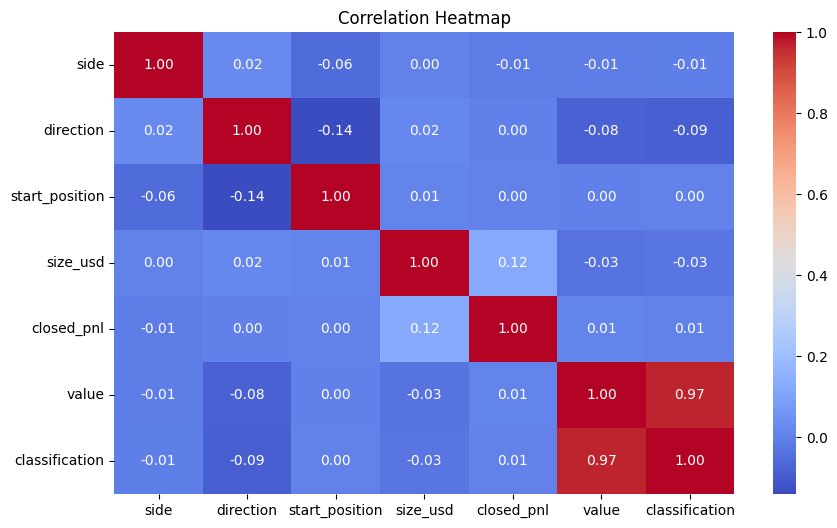

In [28]:
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Q1. Do traders make more money in Fear or Greed?

In [29]:
sample_df=sample.copy()

In [30]:
sample_df.sample(5)

,Timestamp IST,Side,Direction,Start Position,Size USD,Closed PnL,value,classification
133595,2025-03-11 08:27:00+05:30,SELL,Close Long,1294.660000,605.12,36.055200,20,Extreme Fear
184176,2025-04-18 17:40:00+05:30,SELL,Open Short,0.000000,554.99,0.000000,33,Fear
129591,2025-03-10 17:25:00+05:30,SELL,Sell,1415.847574,2065.60,49.443028,20,Extreme Fear
6926,2024-04-05 14:56:00+05:30,SELL,Close Long,65687.000000,376.09,20.613380,79,Extreme Greed
152524,2025-03-26 20:34:00+05:30,SELL,Open Short,-4542.010000,5052.94,0.000000,47,Neutral


In [73]:
sample_df = sample_df[sample_df["Closed PnL"] != 0]
sample_df["return"] = sample_df["Closed PnL"] / sample_df["Size USD"]
sample_df["is_profit"] = sample_df["Closed PnL"] > 0

metrics = sample_df.groupby("classification").agg(
    avg_pnl=("Closed PnL", "mean"),
    median_pnl=("Closed PnL", "median"),
    win_rate=("is_profit", "mean"),
    total_pnl=("Closed PnL", "sum"),
    trade_count=("Closed PnL", "count"),
    avg_return=("return", "mean")
).reset_index()

metrics

,classification,avg_pnl,median_pnl,win_rate,total_pnl,trade_count,avg_return
0,Extreme Fear,86.494484,9.265000,0.797684,9.709006e+05,11225,0.016769
1,Extreme Greed,120.748591,8.248292,0.892259,2.536203e+06,21004,0.072555
2,Fear,105.548379,6.328150,0.866711,2.989341e+06,28322,0.024912
3,Greed,105.172215,6.306648,0.792374,2.545904e+06,24207,0.050337
4,Neutral,63.847834,3.092146,0.786056,1.254610e+06,19650,0.019089


## Average PnL by Market Sentiment



**Profitability (Average PnL)**

**Fear:**

Fear: 105.5

Extreme Fear: 86.5

**Greed:**

Greed: 105.2

Extreme Greed: 120.7 **(highest)**


--> Greed (especially Extreme Greed) has higher average profits.



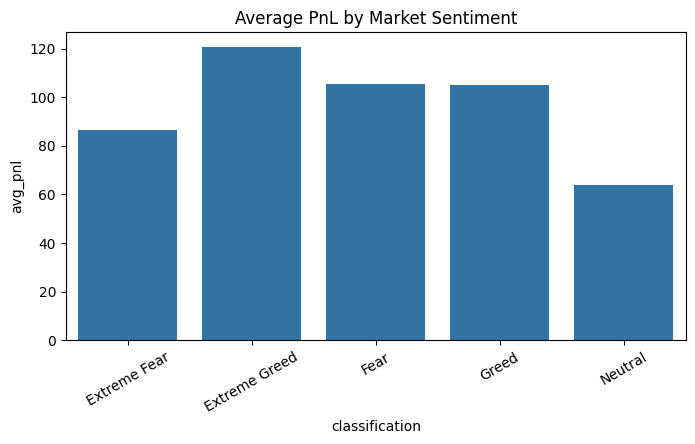

In [39]:
plt.figure(figsize=(8,4))

sns.barplot(data=metrics, x="classification", y="avg_pnl")
plt.title("Average PnL by Market Sentiment")
plt.xticks(rotation=30)
plt.show()

## Win Rate by Market Sentiment

**Consistency (Win Rate)**

**Fear:**

Fear: 86.7%

Extreme Fear: 79.7%

**Greed:**

Greed: 79.2%

Extreme Greed: 89.2% **(highest)**

--> Mixed, but Extreme Greed is most consistent

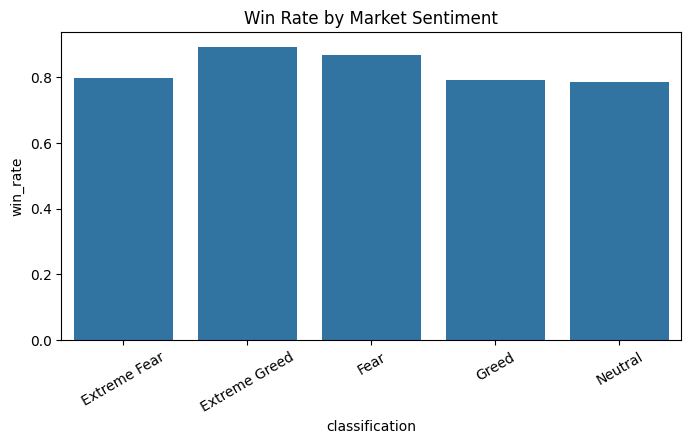

In [42]:
plt.figure(figsize=(8,4))
sns.barplot(data=metrics, x="classification", y="win_rate")
plt.title("Win Rate by Market Sentiment")
plt.xticks(rotation=30)
plt.show()

## Average Return by Market Sentiment

**Average Return**

**Fear:**

Fear: 2.49%

Extreme Fear: 1.67%

**Greed:**

Greed: 5.03%

Extreme Greed: 7.25% 

--> Greed has better Average returns as compared to Fear.

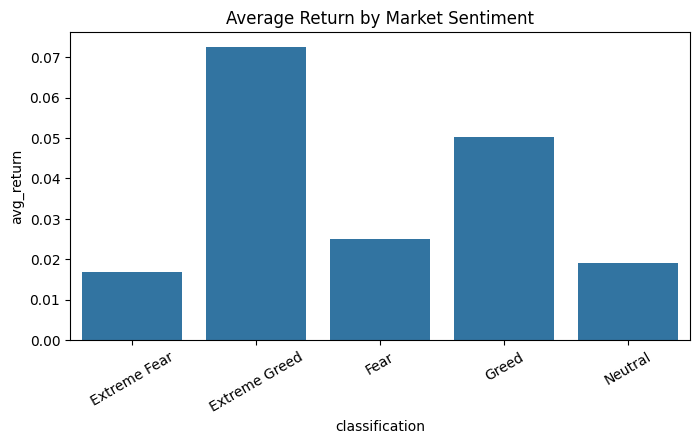

In [46]:
plt.figure(figsize=(8,4))

sns.barplot(data=metrics, x="classification", y="avg_return")
plt.title("Average Return by Market Sentiment")
plt.xticks(rotation=30)
plt.show()

## Total PnL by Market Sentiment

While Fear shows the highest total PnL, this is largely driven by a higher number of trades rather than superior per-trade performance. When normalized using average returns, Greed—especially Extreme Greed—outperforms Fear. Therefore, total PnL alone is not a reliable indicator of trading efficiency.

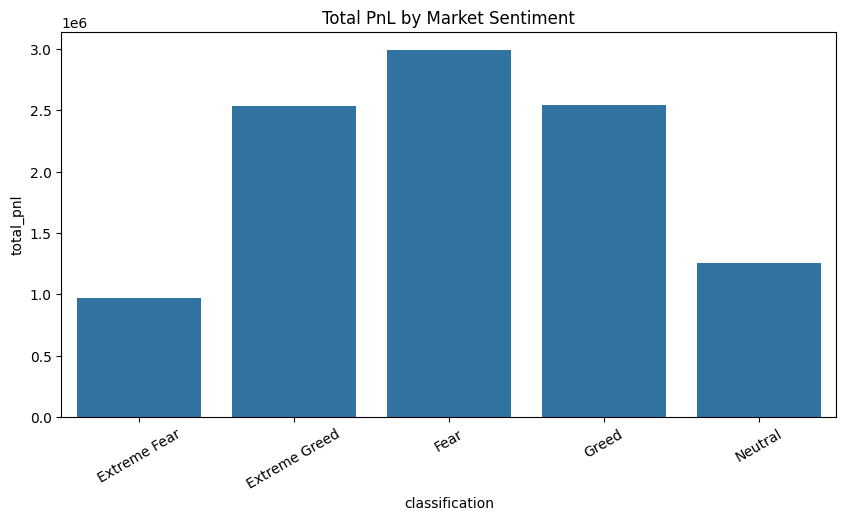

In [77]:
plt.figure(figsize=(10,5))
sns.barplot(data=metrics, x="classification", y="total_pnl")
plt.title("Total PnL by Market Sentiment")
plt.xticks(rotation=30)
plt.show()


## Insights


**Greed is more profitable for traders than fear.Higher average PnL, noticeably higher returns per trade, and higher overall profits during periods of greed all support this.Specifically, Extreme Greed exhibits the best performance in every important metric, including the highest win rate and average returns.Fear conditions still have comparatively high win rates, but their returns are lower, suggesting that trades in Fear are typically smaller or less profitable.Furthermore, the low median PnL across all sentiments indicates that a few big winning trades, particularly during periods of greed, drive overall profitability.**


# Q2. How do traders behave in Fear vs Greed?

In [48]:
sample_df2=sample.copy()

## PnL Distribution by Market Sentiment

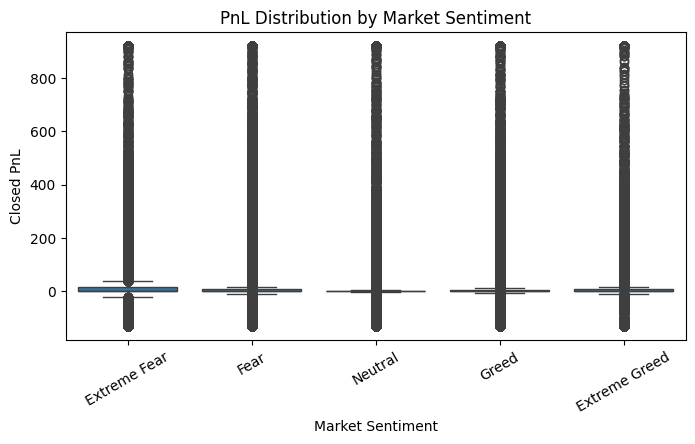

In [74]:
lower = sample_df2["Closed PnL"].quantile(0.01)
upper = sample_df2["Closed PnL"].quantile(0.99)
sample_df2["closed_pnl_clipped"] = sample_df2["Closed PnL"].clip(lower, upper)

order = ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]

plt.figure(figsize=(8,4))

sns.boxplot(
    data=sample_df2,
    x="classification",
    y="closed_pnl_clipped",
    order=order
)

plt.title("PnL Distribution by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")

plt.xticks(rotation=30)
plt.show()

In [75]:
sample_df2["trade_type"] = sample_df2["Direction"].apply(
    lambda x: "Long" if "Long" in x or "buy" in x else ("Short" if "Short" in x or "sell" in x else "Other")
)

sample_df2 = sample_df2[sample_df2["trade_type"].isin(["Long", "Short"])]

In [76]:
direction_dist = (
    sample_df2.groupby(["classification", "trade_type"])
    .size()
    .reset_index(name="count")
)

direction_dist["percent"] = direction_dist.groupby("classification")["count"]\
    .transform(lambda x: x / x.sum())

## Long vs Short Distribution by Sentiment

- Traders exhibit **contrarian behavior**:
  - More **long positions in Fear** (buying dips)
  - More **short positions in Greed** (anticipating reversals)  



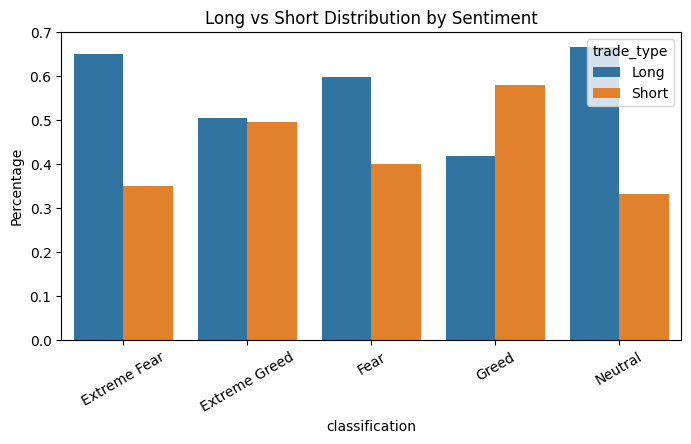

In [56]:
plt.figure(figsize=(8,4))
sns.barplot(
    data=direction_dist,
    x="classification",
    y="percent",
    hue="trade_type"
)
plt.title("Long vs Short Distribution by Sentiment")
plt.xticks(rotation=30)
plt.ylabel("Percentage")
plt.show()

## Average Trade Size by Sentiment

Trade size patterns show that traders adopt more conservative position sizes during times of fear and take on more risk during periods of greed. This behavior is indicative of cautiousness during uncertain market periods and confidence-driven risk-taking in bullish environments.

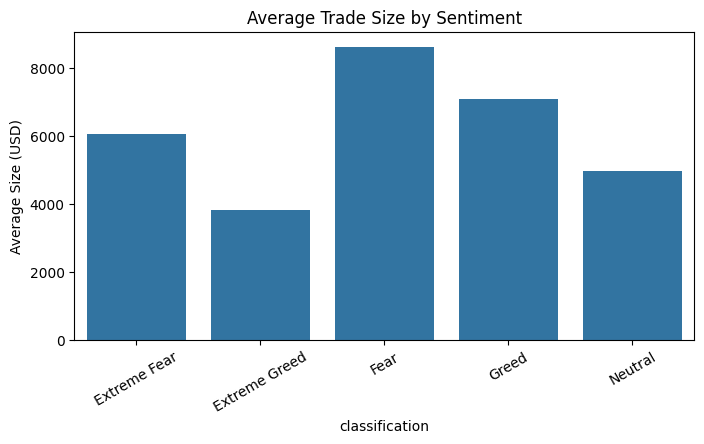

In [58]:
size_analysis = sample_df2.groupby("classification")["Size USD"].mean().reset_index()

plt.figure(figsize=(8,4))
sns.barplot(data=size_analysis, x="classification", y="Size USD")
plt.title("Average Trade Size by Sentiment")
plt.xticks(rotation=30)
plt.ylabel("Average Size (USD)")
plt.show()

## Number of Trades by Sentiment

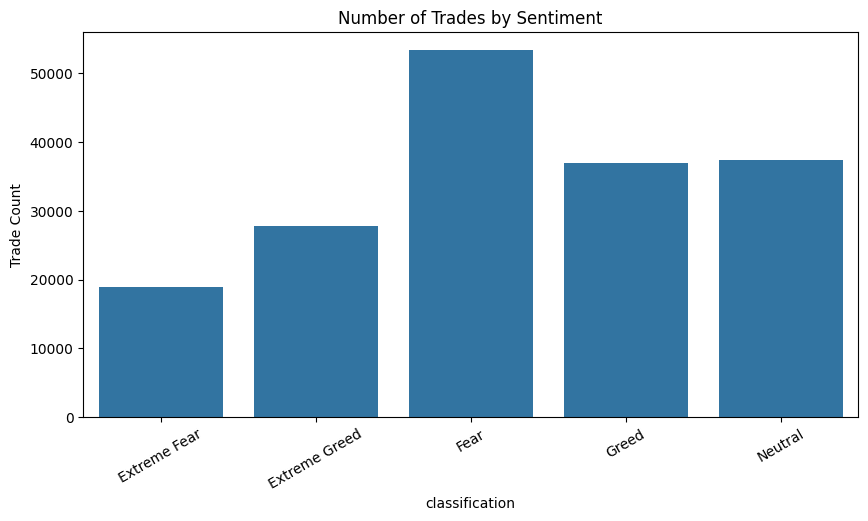

In [59]:
activity = sample_df2.groupby("classification").size().reset_index(name="trade_count")

plt.figure(figsize=(10,5))
sns.barplot(data=activity, x="classification", y="trade_count")
plt.title("Number of Trades by Sentiment")
plt.xticks(rotation=30)
plt.ylabel("Trade Count")
plt.show()

# Q3. What strategy can be derived from this?

In [62]:
df_q3 = sample.copy()

df_q3 = df_q3[df_q3["classification"] != "Neutral"]

#Sentiment group
df_q3["sentiment_group"] = df_q3["classification"].map({
    "Extreme Fear": "Fear",
    "Fear": "Fear",
    "Greed": "Greed",
    "Extreme Greed": "Greed"
})
df_q3 = df_q3.dropna(subset=["sentiment_group"])
df_q3["is_profit"] = df_q3["Closed PnL"] > 0
df_q3["return"] = df_q3["Closed PnL"] / df_q3["Size USD"]

In [69]:
greed_strategy = df_q3[df_q3["sentiment_group"] == "Greed"]

greed_metrics = greed_strategy.agg({
    "Closed PnL": ["mean", "sum"],
    "return": "mean",
    "is_profit": "mean"
})

print("Greed Metrics:")
greed_metrics

Greed Metrics:


,Closed PnL,return,is_profit
mean,5.751853e+01,0.03105,0.429196
sum,5.082107e+06,NaN,NaN


In [68]:
fear_strategy = df_q3[df_q3["sentiment_group"] == "Fear"]

fear_metrics = fear_strategy.agg({
    "Closed PnL": ["mean", "sum"],
    "return": "mean",
    "is_profit": "mean"
})

print("Fear Metrics:")
fear_metrics

Fear Metrics:


,Closed PnL,return,is_profit
mean,4.945172e+01,0.011162,0.418328
sum,3.960242e+06,NaN,NaN


In [67]:
strategy_compare = df_q3.groupby("sentiment_group").agg(
    avg_pnl=("Closed PnL", "mean"),
    total_pnl=("Closed PnL", "sum"),
    avg_return=("return", "mean"),
    win_rate=("is_profit", "mean"),
    trades=("Closed PnL", "count")
).reset_index()

strategy_compare

,sentiment_group,avg_pnl,total_pnl,avg_return,win_rate,trades
0,Fear,49.451716,3.960242e+06,0.011162,0.418328,80083
1,Greed,57.518530,5.082107e+06,0.031050,0.429196,88356


## Strategy Comparison: Return

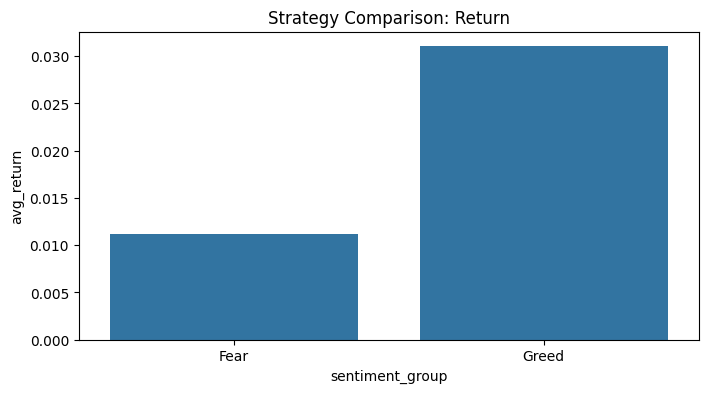

In [70]:
plt.figure(figsize=(8,4))
sns.barplot(data=strategy_compare, x="sentiment_group", y="avg_return")
plt.title("Strategy Comparison: Return")
plt.show()

## Strategy Comparison: Win Rate

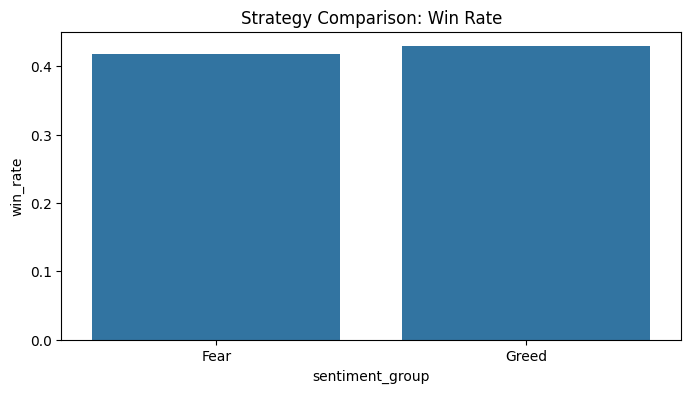

In [71]:
plt.figure(figsize=(8,4))
sns.barplot(data=strategy_compare, x="sentiment_group", y="win_rate")
plt.title("Strategy Comparison: Win Rate")
plt.show()

## Strategy Comparison: Total PnL

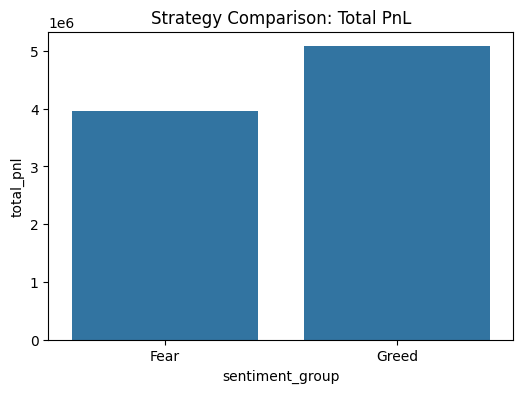

In [72]:
plt.figure(figsize=(6,4))
sns.barplot(data=strategy_compare, x="sentiment_group", y="total_pnl")
plt.title("Strategy Comparison: Total PnL")
plt.show()

## Insights

**When we look at both performance and behavior together, it becomes clear that market sentiment provides useful context for making trading decisions. Traders tend to earn higher returns during strongly bullish or greedy market conditions, which suggests that these periods offer more opportunities. At the same time, traders also take on larger risks in these environments, making careful position sizing essential. A practical takeaway is to stay active when the market is strong and optimistic, but remain cautious and manage risk more tightly during fearful or uncertain periods.**